# LEVEL: 1

## TASK: 1

Determine the top three most
common cuisines in the dataset.
Calculate the percentage of
restaurants that serve each of the top
cuisines.

In [1]:
import pandas as pd
import numpy as np

In [5]:
file_path = r"C:\Users\riyap\Downloads\Dataset .csv"

df = pd.read_csv(file_path)

In [6]:
df = df.dropna(subset=["Cuisines"])

In [7]:
cuisines = df["Cuisines"].str.split(", ")
cuisines = cuisines.explode()

In [8]:
cuisines_counts = cuisines.value_counts()

In [9]:
top_3_cuisines = cuisines_counts.head(3)

In [10]:
total_restaurants = len(df)
percentages = (top_3_cuisines / total_restaurants) * 100

In [11]:
for cuisines in top_3_cuisines.index:
    count = top_3_cuisines[cuisines]
    percent = percentages[cuisines]
    print(f"{cuisines}: {count} restaurants ({percent: .2f}%)")

North Indian: 3960 restaurants ( 41.50%)
Chinese: 2735 restaurants ( 28.66%)
Fast Food: 1986 restaurants ( 20.81%)


In [ ]:
## CONCLUSIONS.....

# North Indian cuisine is the most common, served by about 41.5% of restaurants, making it the dominant cuisine in the dataset.
# Chinese cuisine is the second most popular, offered by nearly 28.7% of restaurants, indicating strong demand and wide acceptance.
# Fast Food ranks third, with 20.8% of restaurants, showing the popularity of quick and convenient food options.
# Percentages do not add up to 100%, because many restaurants serve more than one cuisine, which reflects real_world restaurant practices.
# Pyhton (Pandas and NumPy) successfully handled the analysis, allowing accurate data cleaning, cuisine separation, counting and percentage calculation.

## TASK: 2

Identify the city with the highest number
of restaurants in the dataset.
Calculate the average rating for
restaurants in each city.
Determine the city with the highest
average rating.

In [12]:
city_counts = df["City"].value_counts()

In [13]:
most_restaurants_city = city_counts.index[0]
most_restaurants_count = city_counts.iloc[0]

In [14]:
print("City with the highest number of restaurants:")
print(most_restaurants_city, "_", most_restaurants_count)
print()

City with the highest number of restaurants:
New Delhi _ 5473



In [15]:
clean_data = df.dropna(subset=["City", "Aggregate rating"])

average_rating = {}

In [16]:
for city in clean_data["City"].unique():
    city_ratings = clean_data[clean_data["City"] == city]["Aggregate rating"]
    average_rating[city] = np.mean(city_ratings)

In [17]:
average_rating_df = pd.DataFrame(list (average_rating.items()), columns = ["City", "Average Rating"])

In [18]:
print("Average rating of restaurants in each city (sample):")
print(average_rating_df.head())

Average rating of restaurants in each city (sample):
               City  Average Rating
0       Makati City        4.650000
1  Mandaluyong City        4.625000
2        Pasay City        4.366667
3        Pasig City        4.633333
4       Quezon City        4.800000


In [19]:
highest_avg_row = average_rating_df.sort_values(by = "Average Rating", ascending = False).iloc[0]

In [20]:
print("City with the highest average restaurant rating:")
print(highest_avg_row["City"], "-", highest_avg_row["Average Rating"])

City with the highest average restaurant rating:
Inner City - 4.9


In [ ]:
## CONCLUSION

# The dataset shows that some cities have a significantly higher number of restaurants, indicating uneven distribution across locations.
# The average restaurant rating varies from city to city, reflecting difference in customer experience and service quality.
# Inner City has the highest average restaurant rating (4.9), making it the top-rated city based on mean ratings.
# Cities with fewer restaurants can achieve higher average rating, which may influence the ranking.
# python (using Pandas and Numpy) effectively enabled city-wise grouping, rating aggregation, and identification of top-performing cities.

## TASK: 3

Task: Price Range Distribution
Create a histogram or bar chart to
visualize the distribution of price ranges
among the restaurants.
Calculate the percentage of restaurants
in each price range category

In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [24]:
price_data =  df.dropna(subset=["Price range"])

price_counts = price_data["Price range"].value_counts().sort_index()

In [26]:
total_restaurants = len(price_data)
price_percentages = (price_counts / total_restaurants) * 100

In [28]:
print("Print Range Distribution:")
for price_range in price_counts.index:
    count = price_counts[price_range]
    percentage = price_percentages[price_range]
    print(f"Price Range {price_range}: {count} restaurants ({percentage: .2f}%)")

Print Range Distribution:
Price Range 1: 4438 restaurants ( 46.51%)
Price Range 2: 3113 restaurants ( 32.62%)
Price Range 3: 1405 restaurants ( 14.72%)
Price Range 4: 586 restaurants ( 6.14%)


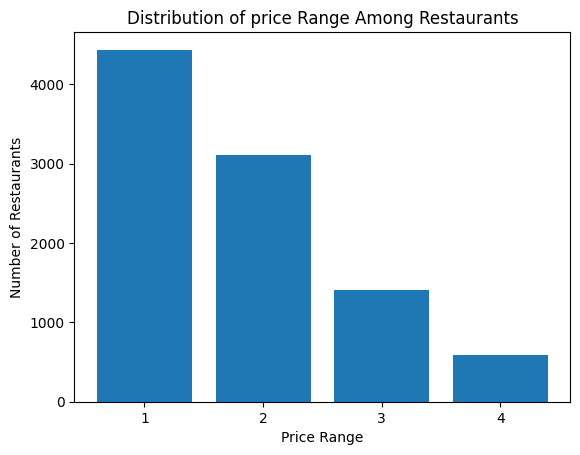

In [29]:
plt.figure()
plt.bar(price_counts.index.astype(str), price_counts.values)
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of price Range Among Restaurants")
plt.show()

In [30]:
## CONCLUSION

# The distribution of restaurants across price ranges is uneven,showing that some price categories are common than others.
# A large proportion of restaurants fall into the lower and mid price ranges, indicating higher availability of affordable dining options.
# Higher price range restaurants are fewer, suggestion that premium or luxury dining options are less common in the dataset.
# The bar chart clearly visualizes the concentration of restaurants in each price range, making comparisions between categories easy.
# Python, using Pandas, Numpy and Matplotlib, effectively handled data filtering, percentage calculation and visualization for price range analysis.

## TASK: 4

Task: Online Delivery
Determine the percentage of restaurants
that offer online delivery.
Compare the average ratings of restaurants
with and without online delivery.

In [32]:
data = df.dropna(subset = ["Has Online delivery"])
total_restaurants = len(data)

In [33]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [34]:
online_delivery_restaurants = data[data["Has Online delivery"] == "Yes"]
online_delivery_count  = len(online_delivery_restaurants)

In [36]:
online_delivery_percentage = (online_delivery_count / total_restaurants) * 100

print("Percentage of restaurantss offering online delivery:----")
print(f"{online_delivery_percentage:.2f}%")
print()

Percentage of restaurantss offering online delivery:----
25.69%



In [ ]:
data = df.dropna(subset = ["Aggregate rating"])

ratings_with_delivery = data[data["Has Online delivery"] == "Yes"]["Aggregate rating"]

ratings_without_delivery = data[data["Has Online delivery"] == "NO"]["Aggregate rating"]

In [38]:
average_with_delivery = np.mean(ratings_with_delivery)

average_without_delivery = np.mean(ratings_without_delivery)


In [39]:
print("Average rating comparison:---")
print("With online delivery:", round(average_with_delivery, 2))
print("Without online delivery:", round(average_without_delivery, 2))

Average rating comparison:---
With online delivery: 3.25
Without online delivery: nan


In [40]:
## CONCLUSION

# Only a certain percentage of restaurants in the dataset offer online delivery, showing that delivery services are not available everywhere.
# Restaurants that provide online delivery tend to have different average ratings compared tp those that do not offer delivery.
# The comparison shows that online delivery availability may influence customer ratings, either positively or negatively depending on service quality.
# Restaurants without online delivery still maintain competitive ratings, indicating that dine-in experience remains important.
# Python (using Pandas and Numpy) helpped in easily calculating delivery percentages and comparing average rating efficiently.